In [1]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [2]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

In [3]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

sat = sim.particles[2]
jup = sim.particles[1]

pvars = Poincare.from_Simulation(sim)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010490552406695942
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:35<00:00, 2807.38it/s]


-0.00010490552407149293
Energy Percent Change: 4.321517012003617e-09 %
*** Simulation Complete ***
Time elapsed  = 35.646346215999074 seconds


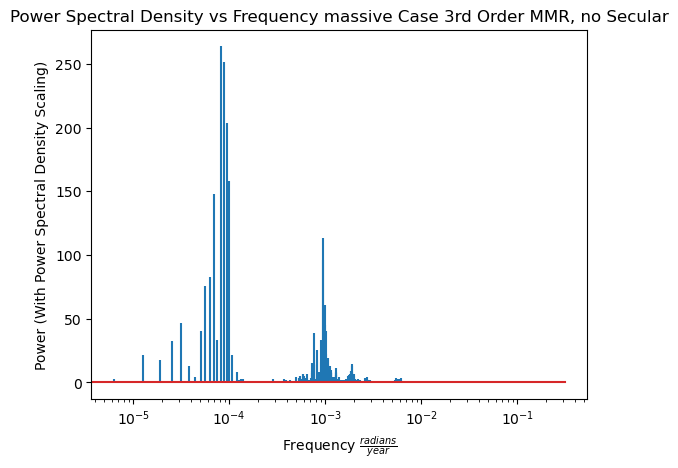

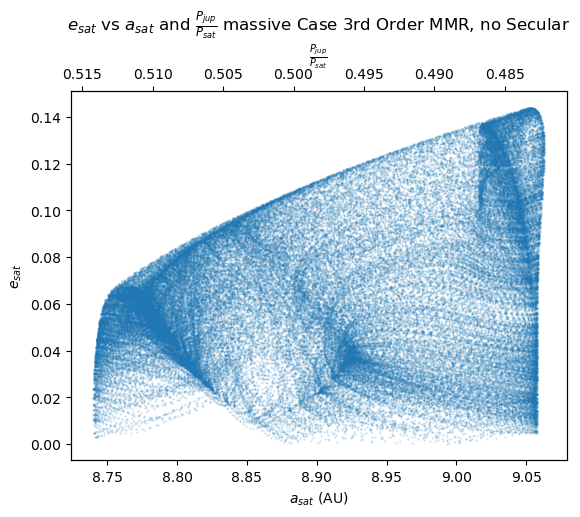

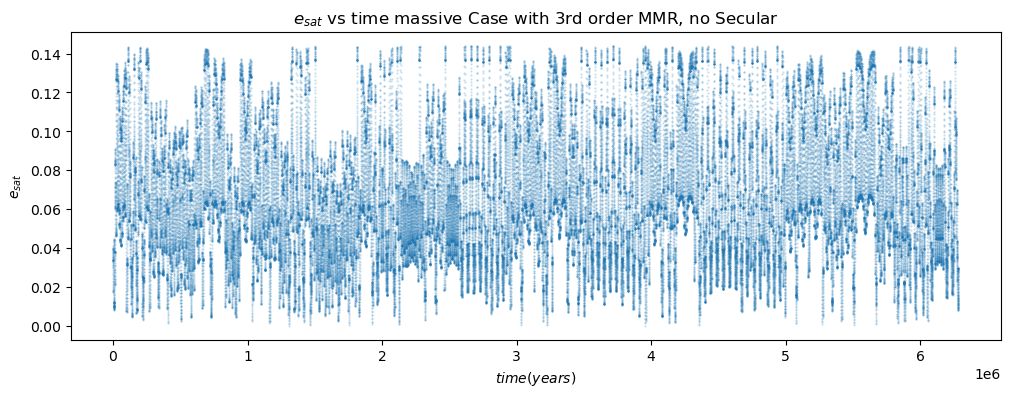

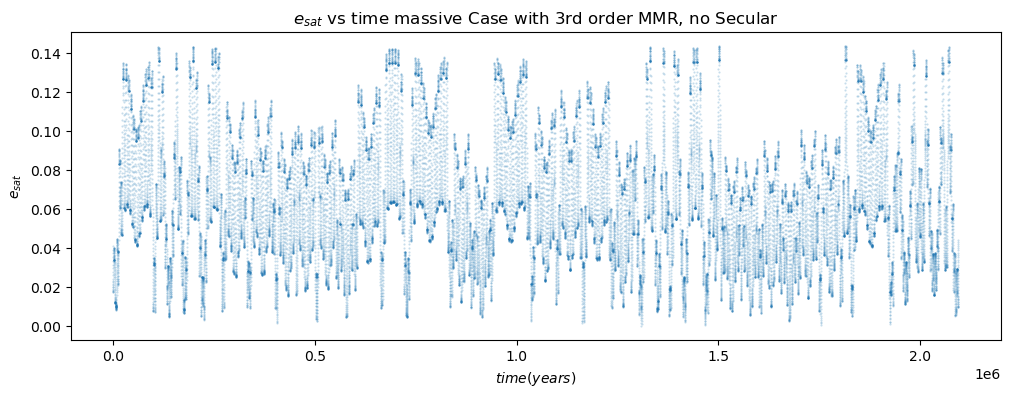

In [4]:
#experiment 2d no secular

pham_3 = PoincareHamiltonian(pvars)
pham_3.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 3)

times, pomega_sat, pomega_j, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham_3, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency massive Case 3rd Order MMR, no Secular')
plt.show()

plt.title(r'$e_{sat}$ vs $a_{sat}$ and $\frac{P_{jup}}{P_{sat}}$ massive Case 3rd Order MMR, no Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat, e_sat, s = 0.25, alpha = 0.25)

top_axis = plt.gca().twiny()

top_axis.set_xlabel(r'$\frac{P_{jup}}{P_{sat}}$')
plt.scatter(np.sqrt(a_jup**3)/np.sqrt(a_sat**3), e_sat, s = 0, alpha = 0)
top_axis.invert_xaxis()

plt.show()

plt.subplots(figsize=(12, 4))
plt.title(r'$e_{sat}$ vs time massive Case with 3rd order MMR, no Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$time (years)$')
plt.scatter(times,e_sat, s = 0.25, alpha = 0.25)
plt.show()

plt.subplots(figsize=(12, 4))
plt.title(r'$e_{sat}$ vs time massive Case with 3rd order MMR, no Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$time (years)$')
plt.scatter(times[0:int(len(times)/3)],e_sat[0:int(len(times)/3)], s = 0.25, alpha = 0.25)
plt.show()